In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score

## Task 1: Identify Prediciton Target
Lecture material: Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection).

• Inspect the dataset and identify which column should be treated as the target variable for this assignment.

• Justify why this column represents the appropriate prediction objective in the context of the marketing campaign.

• Identify at least two other variables that could superficially appear to be valid targets and explain why they should not be treated as the prediction objective.


From our initial inspection of the dataset, we can determine that the target variable for this assessment is column "y". We can come to this conclusion because this column designates whether a customer ended up subscribing to a term deposit after being contacted by the bank. Therefore, we want our model to predict this value. One other variable that may appear to be our target variable is "duration" which measures the duration of the call since we could assume that longer calls mean that the customer is interested and that they are more likely to a successful signup. But this is not a valit target since call duration is only determined after the call ends which defeats the purpose of a predictive model. Another variable that may appear to be the target variable is "poutcome" since its values (failure, success, unknown) seem like they would indicate the success of the campaign. This variable misdirects since actually represents the outcome of a past campaign not the current one.


In [51]:

df = pd.read_csv("data/bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Task 2: Data Loading & Exploration
Lecture material: Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection and EDA).

• Load the dataset into a Pandas DataFrame.

• Inspect the structure of the dataset: number of observations, number of features, data types, and basic summary statistics.

• Identify which variables are numerical and which are categorical.

• Analyze the distribution of the target variable and comment on potential class imbalance.

• Detect explicit and implicit missing values (e.g., special categories such as unknown).

• Visualize the distribution of at least:
    – two numerical variables; and
    – two categorical variables.

• Identify at least one variable that may require special consideration before modeling (e.g., due to distributional properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.


From this initial data exploration, we determine that the numerical variables are age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m and nr.employed. Meanwhile the categorical variables are: contact, day_of_week, default, education, housing, job, loan, marital, month, poutcome and y. there are 41188 entries in total. There is a large imbalance in the target dataset since more than 88% of the dataset have a no label. This will lead to issues with acurracy which will affect the final performance of the model. In the dataset there are no implicit missing values. There are 7 variables that have explicit missingness: default, education, housing, job, loan, marital, pdays. For all of these variables except for pdays missing values are labled as "unknown". In pdays, we have values labled 999 which indicate that that customer hasn't been contacted before. We will need to adjust this because such a large number disrupts our distributions. One important variable that we have to consider is duration. This variable is very linked to our target variable which causes it to be a risk for data leakage. We drop it since it harms our model more than it helps it.

In [52]:
df = pd.read_csv("data/bank-additional-full.csv", sep=';')

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [54]:
numerical_variables = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_variables = df.columns.difference(numerical_variables).tolist()
print(f"Numerical Variables:\n    {numerical_variables}")
print(f"Categorical Variables:\n    {categorical_variables}")

Numerical Variables:
    ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Variables:
    ['contact', 'day_of_week', 'default', 'education', 'housing', 'job', 'loan', 'marital', 'month', 'poutcome', 'y']


In [55]:
print(df["y"].value_counts())

y
no     36548
yes     4640
Name: count, dtype: int64


In [56]:
print("\nImplicit Missing Values: ")
print(df.isna().sum().sort_values(ascending=False).head(15))


print("\nExplicit Missing Values:")
for cat_column in categorical_variables:
    unknown_count = df[cat_column].value_counts().get("unknown")
    if unknown_count is not None:
        print(f"   {cat_column}: {unknown_count}")


Implicit Missing Values: 
age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
dtype: int64

Explicit Missing Values:
   default: 8597
   education: 1731
   housing: 990
   job: 330
   loan: 990
   marital: 80


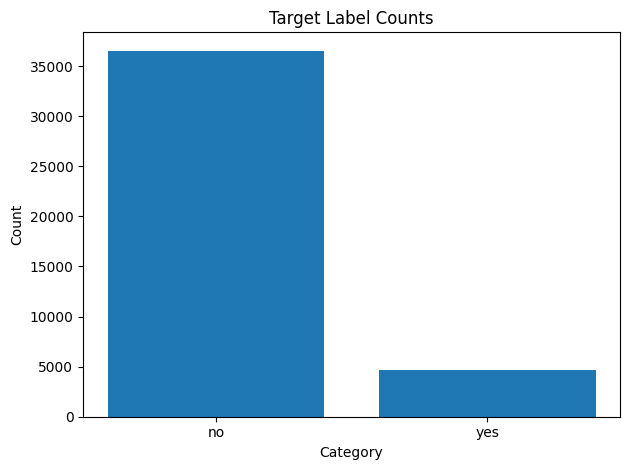

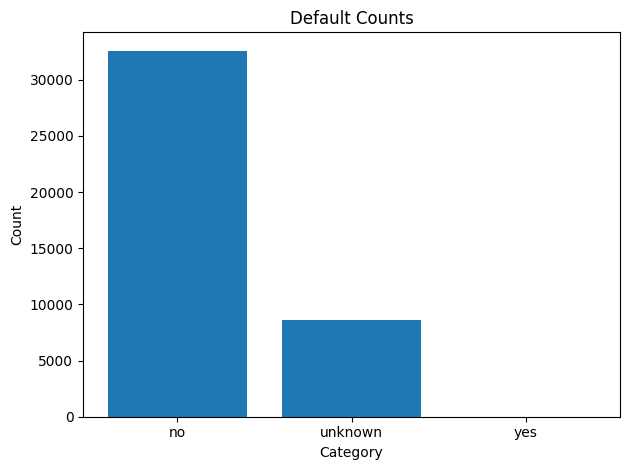

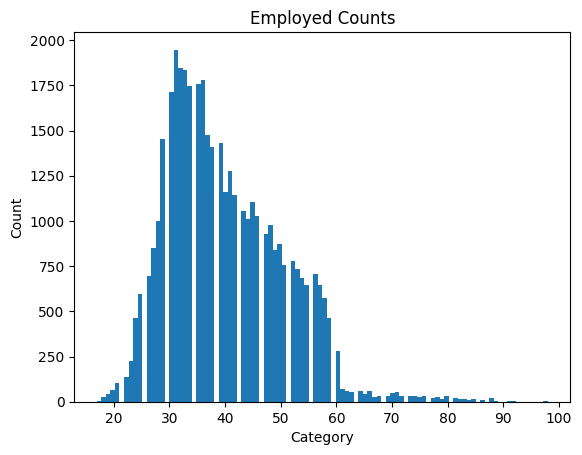

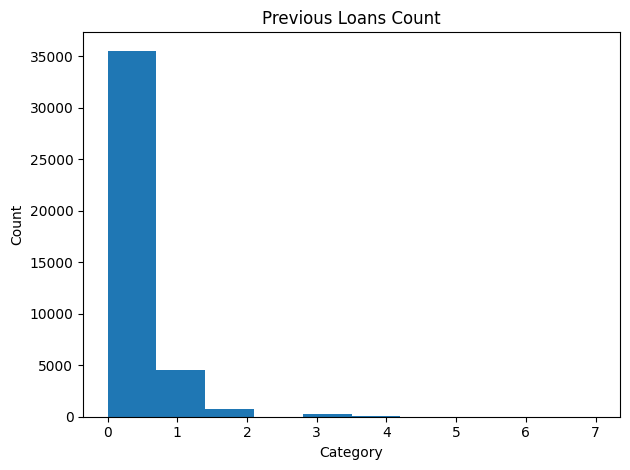

In [57]:



# Visualize the distribution of at least:   
#    – two numerical variables
#    – two categorical variables.


#   - Two Categorical Variables
counts = df["y"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Target Label Counts")
plt.tight_layout()
plt.show()

counts = df["default"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Default Counts")
plt.tight_layout()
plt.show()


#  – Two Numerical Variable

plt.hist(df["age"], bins=100)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Employed Counts")
plt.show()


plt.hist(df["previous"], bins=10)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Previous Loans Count")
plt.tight_layout()
plt.show()

In [58]:
df = df.drop("duration", axis=1)

## Task 3: Data Splitting (Stratified)
Lecture material: Lecture 2 (Data Splitting and Leakage), Lecture 9 (ML Pipeline).

• Split the dataset into training, validation, and test sets.

• Justify your choice of proportions for each split.

• Perform stratified splitting with respect to the target variable and explain why stratification is necessary for this dataset.

• Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage would arise if splitting were performed later.

Note: A recommended strategy is to first split the dataset into a training set and a temporary set, and then split the temporary set into validation and test sets. Use the stratify argument of train test split where appropriate.


Here we split the dataset into 70% train, 15% test and 15% validation sets. This proportion is a good compromise because the training set remains large enough to learn properly while te validation set is big enough to suport model tuning decisions. We apply stratified splitting on the target variable y on both split steps to preserve the original distribution since our target is unbalanced and we don't want to distribute it unevenly. We apply the split before any preprocessing occurs since if we process the data beforehand we risk data leakage from validation into training. 

In [59]:
train, test_val = train_test_split(df, test_size=0.3, random_state=42, stratify=df["y"])
test, val = train_test_split(test_val, test_size=0.5, random_state=42, stratify=test_val["y"])


x_train = train.drop("y", axis=1)
y_train = train["y"]

x_test = test.drop("y", axis=1)
y_test = test["y"]

x_val = val.drop("y", axis=1)
y_val = val["y"]

## Task 4: Missing Value Handling (fit on train)
Lecture material: Lecture 2 (Data Inspection), Lecture 5 (Preprocessing and Pipeline Discipline).

• Identify both explicit missing values (e.g., NaN) and implicit missing values (e.g., categories such as unknown or sentinel numerical values, i.e., values that may represent special codes rather than genuine measurements).

• Quantify the extent of missingness for each affected variable.

• Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate category, indicator variable).

• Clearly state which operations must be fitted using the training set only, and explain why.

Note: Your strategy should distinguish between “data cleaning” decisions (e.g., correcting inconsistent entries) and “modeling” decisions (e.g., whether missingness itself may carry predictive information).


From our code we can determine that there are no explicit missing values. There are 7 variables that have explicit missingness: default, education, housing, job, loan, marital, pdays. For all of these variables except for pdays missing values are labled as "unknown". In pdays, we have sentinel values labled 999 which indicate that that customer hasn't been contacted before. The extent of the missingness is quantified by calculating how many times these values appear in each column. We will be treating unknown as its own category so that the model can learn whether the missingness is informative.For the sentinel value, we replace the 999 with a different code (-1) so that it still provides value without introducing a massive variance we also add a new variable that indicates that the customer has never been contacted. Any operation that learns parameters from data must be fitted on the training set only and then applied unchanged to validation and test sets, to avoid leaking information from validation/test into the preprocessing steps and over‑optimistic performance estimates.

In [60]:
explicit_missing_counts = df.isna().sum().sort_values(ascending=False)
explicit_missing_counts.head(20)

age               0
job               0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
campaign          0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

In [61]:
cat_columns = x_train.select_dtypes(include=["object", "category", "string"]).columns
for cat_column in cat_columns:
    unknown_count = x_train[cat_column].value_counts().get("unknown")
    if unknown_count is not None:
        print(f"   {cat_column}: {unknown_count}")
    

sentinel_count = x_train["pdays"].value_counts().get(999)
print(f"   pdays: {sentinel_count}")

   job: 240
   marital: 58
   education: 1234
   default: 6051
   housing: 707
   loan: 707
   pdays: 27734


In [62]:
report = pd.DataFrame({
    "explicit_na_count": x_train.isna().sum(),
    "explicit_na_pct": x_train.isna().mean()*100,
})

for c in cat_columns:
    report.loc[c, "implicit_unknown_count"] = (x_train[c].astype(str).str.lower() == "unknown").sum()
    report.loc[c, "implicit_unknown_pct"] = report.loc[c, "implicit_unknown_count"]/len(x_train)*100

report.loc["pdays", "implicit_999_count"] = (x_train["pdays"]==999).sum()
report.loc["pdays", "implicit_999_pct"] = report.loc["pdays", "implicit_999_count"]/len(x_train)*100

report.sort_values(by=["explicit_na_count","implicit_unknown_count"], ascending=False).head(30)

,explicit_na_count,explicit_na_pct,implicit_unknown_count,implicit_unknown_pct,implicit_999_count,implicit_999_pct
default,0,0.0,6051.0,20.987826,NaN,NaN
education,0,0.0,1234.0,4.280115,NaN,NaN
housing,0,0.0,707.0,2.452222,NaN,NaN
loan,0,0.0,707.0,2.452222,NaN,NaN
job,0,0.0,240.0,0.832437,NaN,NaN
marital,0,0.0,58.0,0.201172,NaN,NaN
contact,0,0.0,0.0,0.000000,NaN,NaN
month,0,0.0,0.0,0.000000,NaN,NaN
day_of_week,0,0.0,0.0,0.000000,NaN,NaN
poutcome,0,0.0,0.0,0.000000,NaN,NaN


In [63]:
def add_pdays_features(X):
    X = X.copy()
    X["prev_contacted"] = (X["pdays"] != 999).astype(int)
    X["pdays_clean"] = X["pdays"].where(X["pdays"] != 999, -1)
    return X


x_train = add_pdays_features(x_train)
x_val   = add_pdays_features(x_val)
x_test  = add_pdays_features(x_test)

x_train["pdays_clean"].unique()


array([-1,  4, 10,  3,  2,  6, 17,  9, 12, 15, 13, 11, 16,  7, 14,  1,  5,
        0,  8, 22, 19, 18, 26, 21, 20, 27, 25])

## Task 5: Categorical Encoding (Fit on train)

Lecture material: Lecture 4 (Categorical Encoding), Lecture 6 (Linear Models), Lecture 9 (Feature Engineering and Expressiveness).

• Identify all categorical variables in the dataset.

• Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables (categories with a meaningful order, e.g., education level), and justify your classification.

• Select and apply an appropriate encoding strategy for each categorical variable.

• Clearly state which encoders must be fitted on the training set only, and explain why.

• Analyze how encoding changes:

    – the dimensionality of the dataset;

    – the interpretability of model coefficients;
    
    – the types of decision boundaries a linear model can represent.
    
The categorical variables in this dataset are job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, and the target y. Most are nominal with education being the only ordinal variable. For this logistic regression, a safe choice is to treat all categoricals as ordinal and use a one-hot encoder on them. Any encoder that learns from data must be fitted on the training set only and then applied back unchanged to the validation and test sets to avoid leaking information. In terms of decision boundries, a linear model on one-hot features can represent separate linear effects for each category but with one-hot encoding it cannot exploit any ordering.


In [64]:

cat_columns = x_train.select_dtypes(include=["object", "category", "string"]).columns
num_columns = x_train.columns.difference(cat_columns).tolist()

ordinal_columns = ["education"]
nominal_columns = [c for c in cat_columns if c not in ordinal_columns]

In [65]:
ohe_ct = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_columns),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

x_train_ohe = ohe_ct.fit_transform(x_train)
x_test_ohe = ohe_ct.transform(x_test)
x_val_ohe = ohe_ct.transform(x_val)

ohe_feature_names = ohe_ct.get_feature_names_out()

x_train_ohe = pd.DataFrame(x_train_ohe, columns= ohe_feature_names, index=x_train.index)
x_test_ohe = pd.DataFrame(x_test_ohe, columns= ohe_feature_names, index=x_test.index)
x_val_ohe = pd.DataFrame(x_val_ohe, columns= ohe_feature_names, index=x_val.index)

## Task 6: Feature Scaling (fit on train)

Lecture material: Lecture 5 (Feature Scaling), Lecture 6 (Logistic Regression and Optimization).

• Identify the numerical variables that require scaling.

• Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables.

• Justify your choice of scaling method in the context of Logistic Regression.

• Clearly state which transformations must be fitted on the training set only, and explain why.

• Discuss how feature scaling affects:

    – gradient-based optimization;

    – the magnitude and comparability of model coefficients;

    – the interpretation of regularization penalties.

All of the numerical variables apart from binary features in this dataset would benefit from scaling. For logistic regression, one of the standard ways of scaling numerical values is through standardization because it puts all predictors on a comparable scale around zero wich stabilizes the optimization and makes the regularization behave more sensibly. The standardization parameters must only be fitted to the training dataset and then they must be applied unchanged to the test and val data. This is to avoid data leakagefrom those sets into the preprocessing. Proper feature scaling improves gradient-based optimization by making the loss surface more isotropic. it maket the magnitudes of coefficients more comparable since a one unit change in each standarized variable is the same. It also clarigfies the effect of regularization penalties (L1/L2) since the penalty affects each coefficient in roughly the same way.

In [66]:

print("Variances of numerical columns:")
for i in num_columns:
    print(f"    {i}: {round(x_train_ohe[i].var(), 2)}")


standardization = ColumnTransformer(
    transformers=[
        ("Standarize", StandardScaler(), num_columns)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

x_train_std = standardization.fit_transform(x_train_ohe)
x_test_std = standardization.transform(x_test_ohe)
x_val_std = standardization.transform(x_val_ohe)


std_feature_names = standardization.get_feature_names_out()

x_train_std = pd.DataFrame(x_train_std, columns= std_feature_names, index=x_train_ohe.index)
x_test_std = pd.DataFrame(x_test_std, columns= std_feature_names, index=x_test_ohe.index)
x_val_std = pd.DataFrame(x_val_std, columns= std_feature_names, index=x_val_ohe.index)

print(x_train.head())

Variances of numerical columns:
    age: 108.03
    campaign: 7.58
    cons.conf.idx: 21.38
    cons.price.idx: 0.33
    emp.var.rate: 2.47
    euribor3m: 3.01
    nr.employed: 5252.32
    pdays: 36091.13
    pdays_clean: 2.4
    prev_contacted: 0.04
    previous: 0.25
       age          job   marital            education  default housing loan  \
7309    50  blue-collar    single             basic.4y       no      no   no   
4169    51     services   married  professional.course  unknown      no   no   
35810   46   technician  divorced  professional.course       no     yes   no   
9668    46       admin.    single    university.degree       no     yes   no   
34389   25     services    single          high.school       no      no   no   

         contact month day_of_week  ...  pdays  previous     poutcome  \
7309   telephone   may         thu  ...    999         0  nonexistent   
4169   telephone   may         mon  ...    999         0  nonexistent   
35810   cellular   may        

## Task 7: Feature Selection (fit on train)
Lecture material: Lecture 5 (Feature Selection), Lecture 6 (Linear Models), Lecture 9 (Pipeline Discipline).

• Identify and remove features with very low variance, if any. Justify the criterion used to define “low” variance.

• Identify highly correlated numerical features and decide whether any should be removed. Clearly state the threshold used and justify your decision.

• Discuss whether any features should be removed based on conceptual considerations (e.g., redundancy, availability at prediction time, or risk of data leakage).

• Explain why feature selection must be performed using the training set only.

• Discuss the consequences of performing feature selection on the entire dataset before splitting.

In this dataset, certain numerical features have a non-trivial spread, so a reasonable filter can treat any feature with a variance below a small threshold as a constant and remove it since these features contribute almost nothing to the model. Amongst the remaining numerical values, we can find some highly correlated features. In this situation, it is reasonable to remove one of the variables from each of the correlated feature pairs in order to reduce multicollinearity. Apart from this, we can also remove other features such as variables that will not be known at prediction time or those that directly encode the target. all such feature sets must be designed and fitted on the training set only. If feature selection is instead performed on the entire dataset before splitting, the model's choice of features would be informed by the patterns present in what will later become the test/val datasets. In practice this will lead to inflated metrics.

In [67]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(x_train_std)

x_train_var = selector.fit_transform(x_train_std)
x_test_var = selector.transform(x_test_std)
x_val_var = selector.transform(x_val_std)

var_feature_names = selector.get_feature_names_out()

x_train_var = pd.DataFrame(x_train_var, columns= var_feature_names, index=x_train_std.index)
x_test_var = pd.DataFrame(x_test_var, columns= var_feature_names, index=x_test_std.index)
x_val_var = pd.DataFrame(x_val_var, columns= var_feature_names, index=x_val_std.index)


In [68]:
num_x_train_var = x_train_var[num_columns]


corr_matrix = num_x_train_var.corr().abs()


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9
drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Highly correlated pairs (>|0.9|):")
for col in upper.columns:
    high_corr = upper.index[upper[col] > threshold].tolist()
    if high_corr:
        for other in high_corr:
            print(f"{other} – {col}: {upper.loc[other, col]}")

drop.remove("prev_contacted")

print("\nFeatures chosen to drop:")
print(drop)


x_train_sel_corr = num_x_train_var.drop(columns=drop)

Highly correlated pairs (>|0.9|):
emp.var.rate – euribor3m: 0.9721916546813727
emp.var.rate – nr.employed: 0.906024524317847
euribor3m – nr.employed: 0.9448735707557104
pdays – prev_contacted: 0.9999917749253923

Features chosen to drop:
['euribor3m', 'nr.employed']


## Task 8: Address Class Imbalance (train only)

Quantify the class distribution in the training set and explain why imbalance is or is not a concern for this prediction task.

• Propose  a resampling strategy (e.g., random oversampling, SMOTE, or ADASYN). Clearly justify at which stage of the pipeline the resampling step should occur.

• Justify your choice of resampling method in terms of its assumptions and expected effect on the learning algorithm.

• Explain what would happen if resampling were applied before splitting the dataset into training, validation, and test sets. Discuss the implications for model evaluation.

• Briefly discuss how class imbalance affects evaluation metrics such as accuracy, precision, and recall.

In the training set, the target y is heavily skewed toward the “no” class, which means a model can achieve high  accuracy simply by predicting no. This class imbalance is a concern because we care specifically about correctly identifying the minority yes clients who subscribe. A suitable strategy here is to apply SMOTE after all preprocessing steps that learn from X only (encoding, scaling, feature selection) and only on the training set, so that the model sees a more balanced class distribution during learning but the validation and test sets still reflect the true, imbalanced world. Random oversampling makes the learner pay more attention to the minority class without making strong assumptions about local linearity in feature space which is often adequate for a linear model like Logistic Regression. SMOTE assumes that changing between minority examples yields plausible new points, which may or may not hold depending on the feature representation. If resampling were done before splitting into train/validation/test, the same duplicated or synthetic minority examples would leak into all splits, causing the model to see parts of the validation/test data during training and thereby inflating performance estimates and underestimating overfitting. Class imbalance also interacts strongly with evaluation metrics: accuracy can remain high even for a useless classifier that ignores the minority class, while precision for the positive class measures how many predicted subscribers are truly subscribers, and recall measures how many of the actual subscribers the model recovers.

## Task 9: Train Logistic Regression
Lecture material: Lecture 6 (Logistic Regression), Lecture 9–11 (Model Evaluation and Metrics).

• Train a Logistic Regression model to predict whether a client subscribes to a term deposit.

• Use the validation set to generate predictions.

• Report at least Accuracy, Precision, and Recall on the validation set.

• Compare the model’s accuracy with the Zero Rule baseline and briefly interpret the result.

Here we train our logistic regressin model on the preprocessed training data. We then apply the same preprocessing pipeline to the validation set and feed the resuling feature matrix into the trained model to obtain class predictions for each client. We compute accuracy, recall and precision on the validation labels. To interpret performance, we compare our model with the zero rule baseline which always predicts the majority class. our accuracy is weaker than the baseline which indicates that our model is not learning informative patterns.

In [69]:

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(x_train_sel_corr),
    columns=x_train_sel_corr.columns,
    index=x_train_sel_corr.index
)


logreg = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced"
)

logreg.fit(X_train_imputed, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [70]:
x_val_sel_corr = x_val_var[x_train_sel_corr.columns]
X_val_imputed = pd.DataFrame(
    imputer.transform(x_val_sel_corr),
    columns=x_train_sel_corr.columns,
    index=x_val_sel_corr.index
)

y_val_pred = logreg.predict(X_val_imputed)         
y_val_proba = logreg.predict_proba(X_val_imputed)[:, 1] 
acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec  = recall_score(y_val, y_val_pred, pos_label="yes")
print("Validation accuracy:", acc)
print("Validation precision:", prec)
print("Validation recall:", rec)

Validation accuracy: 0.745589901278524
Validation precision: 0.2652733118971061
Validation recall: 0.7112068965517241


In [71]:
majority_class = y_val.value_counts().idxmax()
print("Majority class (Zero Rule):", majority_class)
y_val_baseline = np.full_like(y_val, fill_value=majority_class)
zero_rule_acc = accuracy_score(y_val, y_val_baseline)
print("Zero Rule accuracy (validation):", zero_rule_acc)

model_acc = accuracy_score(y_val, y_val_pred)
print("Model accuracy (validation):", model_acc)

improvement = model_acc - zero_rule_acc
print("Accuracy improvement over Zero Rule:", improvement)


Majority class (Zero Rule): no
Zero Rule accuracy (validation): 0.8873604143065221
Model accuracy (validation): 0.745589901278524
Accuracy improvement over Zero Rule: -0.14177051302799815
